Data analysis on predicting skin cancer legions using image data based on a kaggle dataset of multi-source dermatoscopic images of pigmented legions. 

Our team will be using a Convolutional Neural Network Model to analyze a large collection of multi-source dermatoscopic images of pigmented lesions from Kaggle.

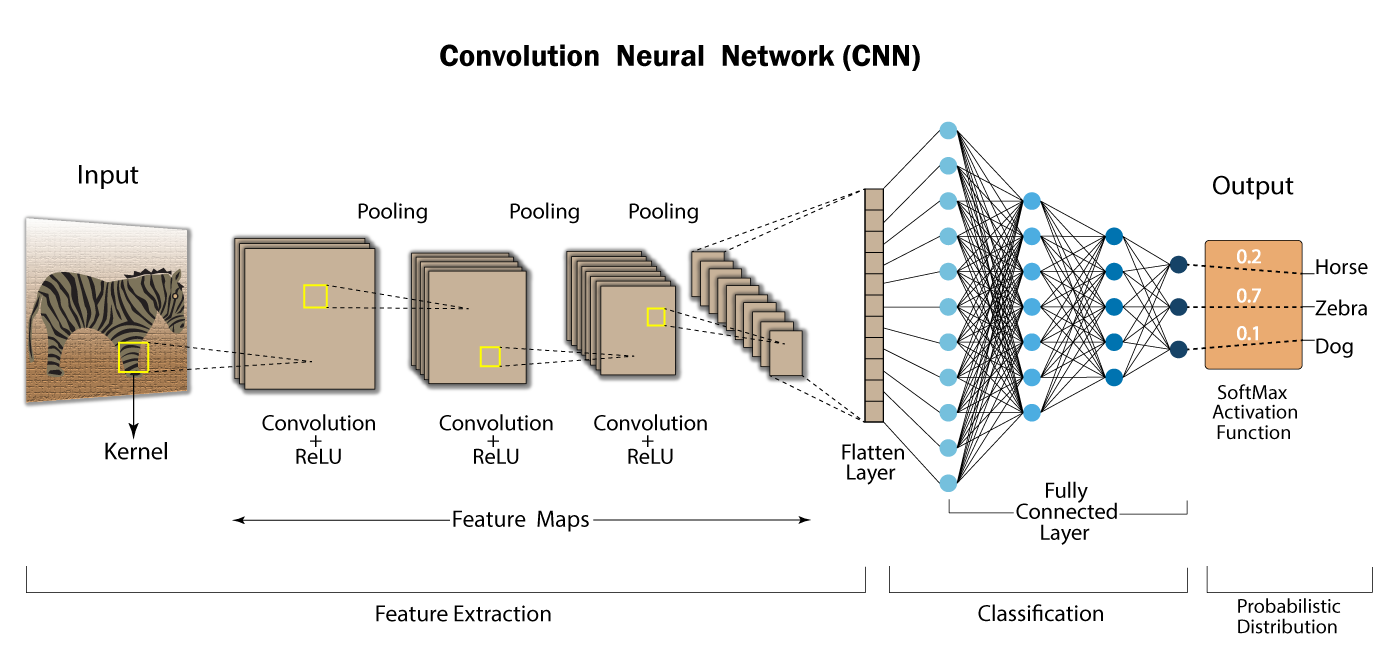

https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

Import the necessary libraries.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Pre-Defined function for showing an image using matplotlib

In [ ]:
#Just throw an image in here.
def ShowImage(img) :
    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap = 'Greys')

The image will be read on a string filepath and read using openCV2, a common package used for
opening file paths, reading them and extracting image array data.

In [ ]:

filePath = '/Users/chazcisneros/Desktop/VSCode\'s/DataScience/Data53FinalProject/archive/HAM10000_images_part_1/ISIC_0024318.jpg'
benignPath = '/Users/chazcisneros/Downloads/archive/benign/1631.jpg'

imgGrey = cv2.imread(filePath, 0)
imgGreyOG = cv2.imread(filePath, 0)
greyRows = len(imgGrey)
greyCols = len(imgGrey[0])


This is the greyscale image of the data we are using to analyze.

In [ ]:
#CHECK ITS SHAPE
imgGrey = np.array(imgGrey)
imgGrey.shape
print(type(imgGrey))  # Should print <class 'numpy.ndarray'>
print(imgGrey.shape)  # Should print (height, width)

As necessary we need to check the shape and type as we build a CNN model. 

In [ ]:
# Get the dimensions
greyRows, greyCols = imgGrey.shape

# Invert the pixel values
for i in range(greyRows):
    for j in range(greyCols):
        imgGrey[i, j] = 255 - imgGrey[i, j]

for i in range(greyRows):
    for j in range(greyCols):
        imgGreyOG[i, j] = 255 - imgGreyOG[i, j]

ShowImage(imgGrey)


We extract dimensions using .shape. .shape() will respectively 
return us the rows and columns. With python we can simply assign it to what .shape() returns.

Next will be the function created to apply a convolution filter. This filter will scan through iteratively collecting a sum of the multiplied pixel values through 
randomized weights. This is a model from google to explain the convolutional layer:

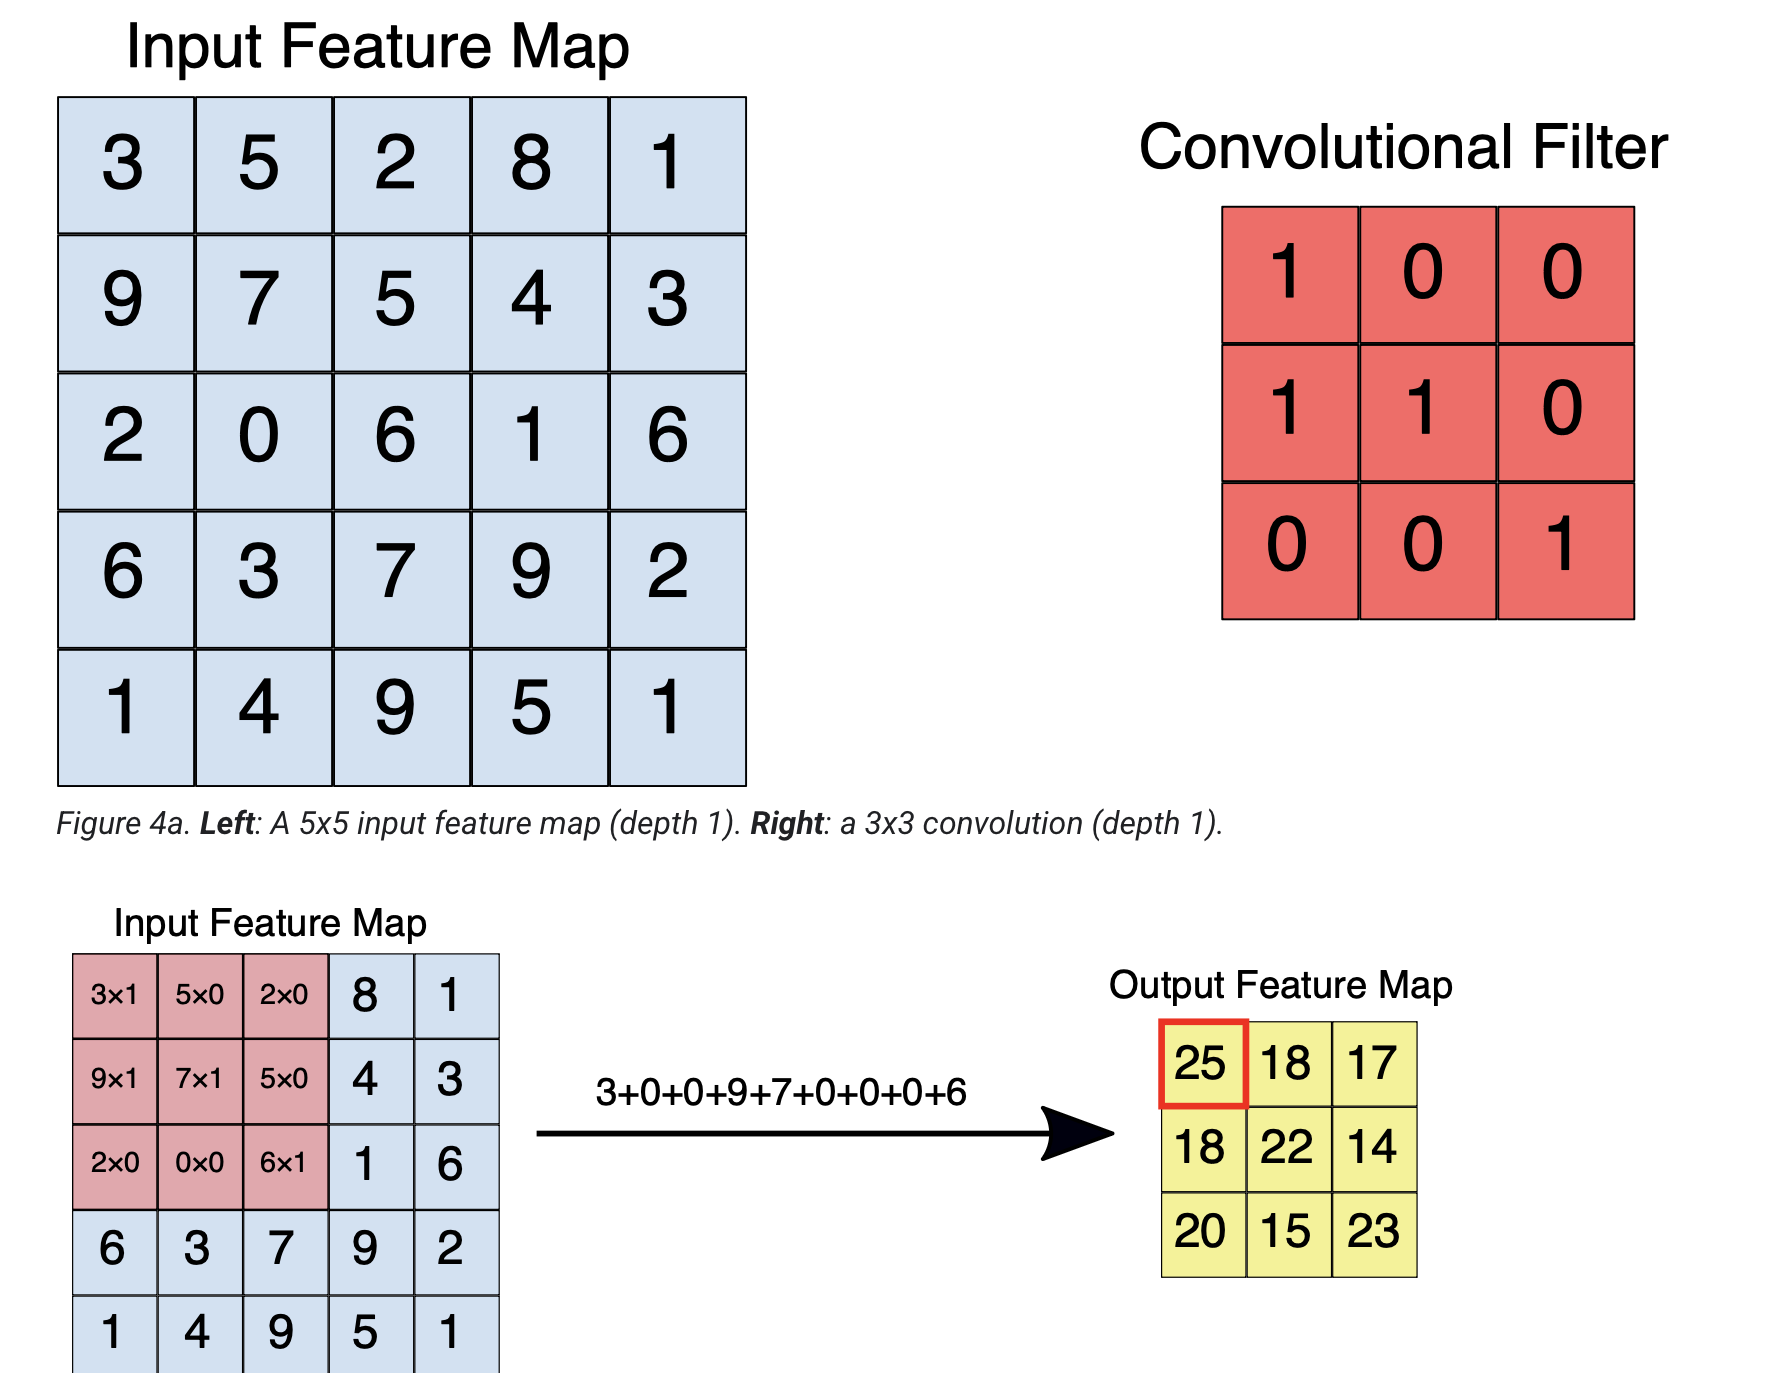


On the code, you can see that it goes through the matrix respective of not leaving the bounds of the matrix's indices.
It collects the sum and appends to a new matrix that will be the result of the conv filter, called an Output Feature Map.



In [ ]:
def ConvFilterApply(arr) :
    i = j = 0
    
    arr = np.array(arr)
         
    arr = arr.astype(np.int32)  # or np.float32
    OutputFeatureMap = []
    arrSum = []
    greyRows = len(arr)
    greyCols = len(arr[0])
    #if the filter is nxn then subtrat n - 1 from the range.
    #5x5 = nxn. 
    for i in range(greyRows - 5):
            #  >>>>>>>>>>  for(int i = 0; i <= (#Rows) - (widthOrHeightOfFilter - 1); i++)
            #              for(int i = 0; i <= 5; i++)
            arrSum = []  # fresh for each row
            for j in range(greyCols - 5):  
                patch = [
                    arr[i][j] * 0,
                    arr[i + 1][j] * 1,
                    arr[i + 2][j] * 0,
                    arr[i + 3][j] * 1,
                    arr[i + 4][j] * 0,

                    arr[i][j + 1] * 0,
                    arr[i + 1][j + 1] * 1,
                    arr[i + 2][j + 1] * 0,
                    arr[i + 3][j + 1] * 1,
                    arr[i + 4][j + 1] * 0,
                    
                    arr[i][j + 2] * 0,
                    arr[i + 1][j + 2] * 1,
                    arr[i + 2][j + 2] * 0,
                    arr[i + 3][j + 2] * 1,
                    arr[i + 4][j + 2] * 0,

                    arr[i][j + 3] * 0,
                    arr[i + 1][j + 3] * 1,
                    arr[i + 2][j + 3] * 0,
                    arr[i + 3][j + 3] * 1,
                    arr[i + 4][j + 3] * 0,

                    arr[i][j + 4] * 0,
                    arr[i + 1][j + 4] * 1,
                    arr[i + 2][j + 4] * 0,
                    arr[i + 3][j + 4] * 1,
                    arr[i + 4][j + 4] * 0,
                ]
                arrSum.append(sum(patch))  
                # sum of this patch
            OutputFeatureMap.append(arrSum)
    # ShowImage(OutputFeatureMap)

    return OutputFeatureMap

ShowImage(imgGrey)

imgGrey = ConvFilterApply(imgGrey)
imgGrey2 = imgGrey


ShowImage(imgGrey)

In [ ]:
def train_filter(image):
    filter_size = 3  
    lr = 0.0001  # Reduced learning rate    
    steps = 10       

    filter = np.random.randn(filter_size, filter_size) * 0.1  # Larger initialization
    image = np.array(image).astype(np.float32)  # Skip normalization
    rows, cols = image.shape  

    for step in range(steps):
        output = []

        for i in range(rows - filter_size + 1):
            row = []
            for j in range(cols - filter_size + 1):
                patch = image[i:i+filter_size, j:j+filter_size]  
                result = np.sum(patch * filter)  
                row.append(result)  
            output.append(row)
        output = np.array(output)  

        # Try mean absolute deviation as the loss function
        error = output - np.mean(output)
        loss = np.mean(np.abs(output - np.mean(output)))  

        grad = np.zeros_like(filter)  
        out_rows, out_cols = output.shape
        for i in range(filter_size):
            for j in range(filter_size):
                patch = image[i:i+out_rows, j:j+out_cols]
                grad[i, j] = np.sum(patch * error)  

        grad = np.clip(grad, -10, 10)  # Loosen gradient clipping
        filter -= lr * grad  # Update filter

        print(f"Step {step + 1}/{steps}, Loss: {loss:.6f}")

    return filter, output


ShowImage(imgGrey)
train_filter(imgGrey)
ShowImage(imgGrey)


In [ ]:
print(type(imgGrey))
print(imgGrey[0])

Max Pooling after first Convolutional Filter. It is standard to be 2x2 size.

Here is our function for scanning the matrix in a similar manner to how we deployed the
convolutional filter. The filter will grab a 2x2 matrix of of the image and find the maximum value
and append that to ANOTHER output map. 

![Screenshot 2025-04-28 at 4.38.58 PM.png](<attachment:Screenshot 2025-04-28 at 4.38.58 PM.png>)

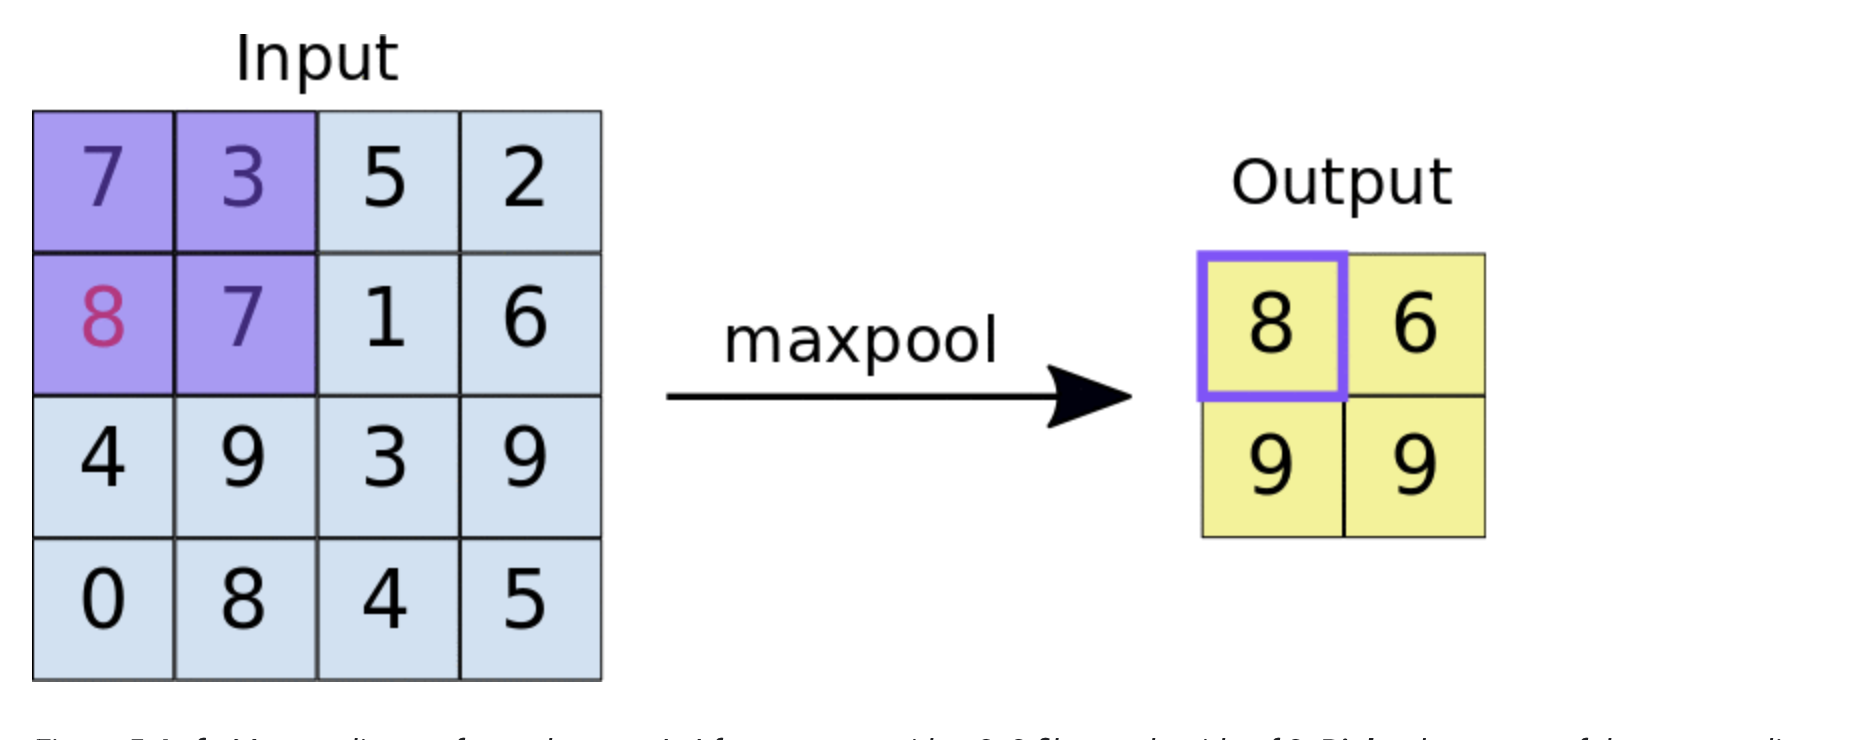

In [ ]:
def PoolMap(arr): #{
    i = j = 0

    PoolMap = []
    arrMax = []

    PoolRows = len(arr)
    PoolCols = len(arr[0])

    for i in range(PoolRows):
        if (i + 1 < PoolRows - 2):  # Make sure i+1 and i+2 exist if needed
            arrMax = []  # fresh for each row
            for j in range(PoolCols - 2):  
                patch = [
                    arr[i][j],
                    arr[i][j + 1],
                    arr[i + 1][j],
                    arr[i + 1][j + 1],
                ]
                arrMax.append(max(patch))  
                # NOW, the MAX using max() of this patch
            PoolMap.append(arrMax)
            
    return PoolMap
#}
def PoolMapMean(arr):
    def Mean(list):
        sum = 0
        for i in range (len(list)):
            sum += list[i]
        
        return sum / len(list)
            
    i = j = 0

    PoolMap = []
    arrMax = []

    PoolRows = len(arr)
    PoolCols = len(arr[0])

    for i in range(PoolRows):
        if (i + 1 < PoolRows - 2):  # Make sure i+1 and i+2 exist if needed
            arrMax = []  # fresh for each row
            for j in range(PoolCols - 2):  
                patch = [
                    arr[i][j],
                    arr[i][j + 1],
                    arr[i + 1][j],
                    arr[i + 1][j + 1],
                ]
                arrMax.append(Mean(patch))  
                # NOW, the MAX using max() of this patch
            PoolMap.append(arrMax)
            
    return PoolMap
#}
imgGrey = PoolMap(imgGrey) #CALLIN THIS IS GIVING ERROR??

plt.figure(figsize= (4,4))
plt.imshow(imgGrey2, cmap='Greys')
plt.figure(figsize= (4,4))
plt.imshow(imgGrey, cmap='Greys')


In [ ]:
imgGrey = ConvFilterApply(imgGrey)
imgGrey = PoolMapMean(imgGrey)
imgGrey = ConvFilterApply(imgGrey)
imgGrey = PoolMapMean(imgGrey)
ShowImage(imgGrey)

ShowImage(imgGreyOG)

Based on google diagram, here is what the fully deployed CNN-model will compose of. After two sets of CNN + MaxPooling, the finalized flattened result is 
sent to a fully connected layer. The "fully connected layer" is also known as a dense neural network. Now that the image is filtered
multiple times, we can use our simplified image data to be processed into a neural network model to find probability using Relu in the hidden layers
and Softamx activation function for our output. This will give us our accuracy. 


![Screenshot 2025-04-28 at 4.41.18 PM.png](<attachment:Screenshot 2025-04-28 at 4.41.18 PM.png>)
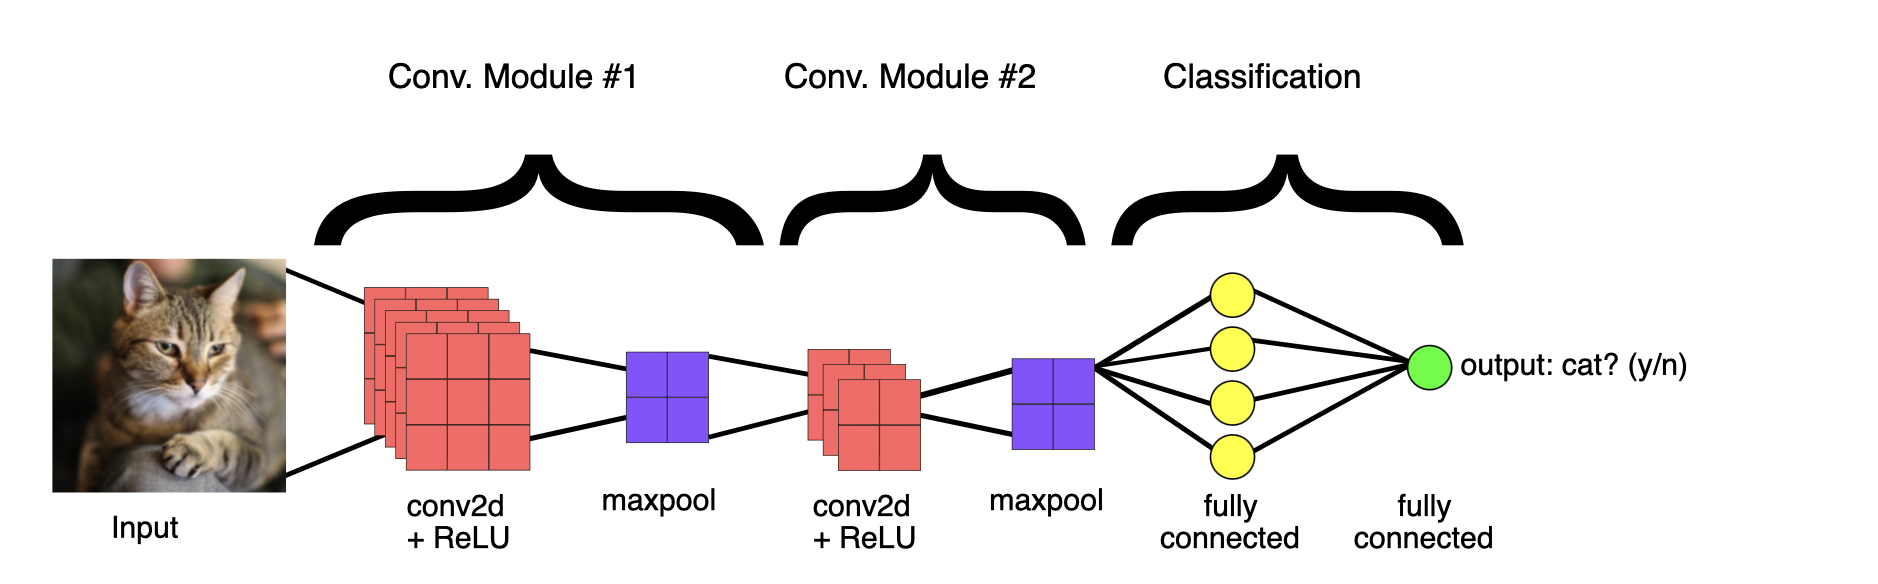

What are we looking for?

Skin lesions use an ABCDE rule:

Asymmetry	One half of the lesion doesn’t match the other half in shape or color.
Border	    Irregular, jagged, blurred, or notched edges rather than smooth.
Color	    Multiple colors (brown, black, red, white, blue) or uneven distribution of color. (no colors for now)
Diameter	Larger than 6 mm (about the size of a pencil eraser), but smaller lesions can still be dangerous.

Evolving	Changes in size, shape, color, or symptoms (itching, bleeding) over time. (we wont worry about this one)

Using the CNN we should be able to train the model on assymetry of skin lesion shapes, jaggedness and irregularities, and larger diameter size.

In [ ]:
imgGrey = np.array(imgGrey)
ShowImage(imgGrey)

Why use a CNN model?


Fully connecting every pixel to every neuron would make the model too big and impossible to train, especially for much higher resolutions.

By us implementing a CNN model we can filter data to its most significant value in order to properly downsize while outputting the most
important information, not losing any features of the image that are needed. 

The healthcare sector has a great need for image recognition, especially in diagnosis. 

In [ ]:
imgGreyF = imgGrey.flatten()

#FIX ME: 
# class Node: 
#     def __init__(self, data):
#         self.data = data
#         self.next = None
#     def pNext()

imgGreyF.size() =

print(imgGreyF)

In [ ]:
print(imgGrey)

imgGrey = np.array(imgGrey)

In [ ]:
base_path = '/Users/chazcisneros/Desktop/VSCode\'s/DataScience/Data53FinalProject/archive/HealthyData/'

# Starting number
start_number = 1

# Number of files to generate
num_files = 15
BenignImages = []
# Generate file paths
for i in range(num_files):
    new_number = start_number + i
    new_file_path = f"{base_path}{str(new_number).zfill(1)}.jpg"
    print(new_file_path)

    imgGrey = cv2.imread(new_file_path, 0)
    greyRows = len(imgGrey)
    greyCols = len(imgGrey[0])


    #CHECK ITS SHAPE
    imgGrey = np.array(imgGrey)
    print(type(imgGrey))  # Should print <class 'numpy.ndarray'>
    print(imgGrey.shape)  # Should print (height, width)

    # Get the dimensions
    greyRows, greyCols = imgGrey.shape

    # Invert the pixel values
    for i in range(greyRows):
        for j in range(greyCols):
            imgGrey[i, j] = 255 - imgGrey[i, j]

    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMapMean(imgGrey)

    ShowImage(imgGrey)
    
    imgGrey = np.array(imgGrey)

    BenignImages.append(imgGrey.flatten())


Here we have written an algorithm to go through our kaggle dataset. By finding that the images are listed by iterative numbers, we can simply
increment by 1 for each image file path and use that as the next image in line. Here we are using 100 images for our training and test data. 

In [ ]:
# Base file path
base_path = '/Users/chazcisneros/Desktop/VSCode\'s/DataScience/Data53FinalProject/archive/HAM10000_images_part_1/'
base_name = 'ISIC_'

# Starting number
start_number = 24313

# Number of files to generate
num_files = 15
FilteredImages = []
# Generate file paths
for i in range(num_files):
    new_number = start_number + i
    new_file_path = f"{base_path}{base_name}{str(new_number).zfill(7)}.jpg"
    print(new_file_path)

    imgGrey = cv2.imread(new_file_path, 0)

    imgGrey = cv2.resize(imgGrey, (224, 224), interpolation=cv2.INTER_AREA)

    greyRows = len(imgGrey)
    greyCols = len(imgGrey[0])


    #CHECK ITS SHAPE
    imgGrey = np.array(imgGrey)
    print(type(imgGrey))  # Should print <class 'numpy.ndarray'>
    print(imgGrey.shape)  # Should print (height, width)

    # Get the dimensions
    greyRows, greyCols = imgGrey.shape

    # Invert the pixel values
    for i in range(greyRows):
        for j in range(greyCols):
            imgGrey[i, j] = 255 - imgGrey[i, j]

    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMapMean(imgGrey)

    ShowImage(imgGrey)
    
    imgGrey = np.array(imgGrey)

    FilteredImages.append(imgGrey.flatten())


Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions: Actinic keratoses and intraepithelial carcinoma / Bowen's disease (akiec), basal cell carcinoma (bcc), benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses, bkl), dermatofibroma (df), melanoma (mel), melanocytic nevi (nv) and vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

https://www.webmd.com/melanoma-skin-cancer/ss/skin-cancer-and-skin-lesions-overview

https://www.google.com/url?sa=i&url=https%3A%2F%2Fnews.christianacare.org%2F2024%2F06%2Fdifferent-types-of-skin-cancer-when-to-worry%2F&psig=AOvVaw3vMA5GQlJG3AMyoEdWcQnS&ust=1745970665650000&source=images&cd=vfe&opi=89978449&ved=0CBYQjRxqFwoTCLixtt31-4wDFQAAAAAdAAAAABAK

The architecture of our Multi-Layer Perceptron is 128 nodes

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Assume FilteredImages and BenignImages are already processed (flattened)
X = np.array(FilteredImages + BenignImages)
y = np.array([1] * len(FilteredImages) + [0] * len(BenignImages))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=70, stratify=y
)

# Test different architectures
hidden_layer_configs = [
    (128,2)
]

accuracies = []
complexities = []

for hidden_layers in hidden_layer_configs:
    print(f"Testing hidden layers: {hidden_layers}")
    
    fc_layer = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=70
    )
    
    fc_layer.fit(X_train, y_train)
    yPred = fc_layer.predict(X_test)
    acc = accuracy_score(y_test, yPred)
    
    complexities.append(sum(hidden_layers))  # total number of neurons = complexity
    accuracies.append(acc)

    print(f"Accuracy: {acc:.4f} | Complexity (neurons): {sum(hidden_layers)}\n")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(complexities, accuracies, marker='o')
plt.title("Model Accuracy vs Complexity (Hidden Layer Size)")
plt.xlabel("Model Complexity (Total Hidden Neurons)")
plt.ylabel("Accuracy Score")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import max_error

print(y_test)
print(yPred)


We set up this model as a binary classification task, labeling images as either benign (0) or cancerous (1). Because of that, the MLPClassifier internally uses a logistic activation at the output, giving us 0/1 predictions based on probability thresholds.

The final output node of the fully connected layer is a sigmoid function. It uses a 0 or 1 output based on if probability <= 0.5 and if probaility is >= 0.5 respectively.



In [ ]:
def SCTest(filePath, fc_layer) :
    
    imgGrey = cv2.imread(filePath, 0)

    imgGrey = cv2.resize(imgGrey, (224, 224), interpolation=cv2.INTER_AREA)

    print(imgGrey.shape)

    greyRows, greyCols = imgGrey.shape
    for i in range(greyRows):
        for j in range(greyCols):
            imgGrey[i, j] = 255 - imgGrey[i, j]

    ShowImage(imgGrey)

    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMap(imgGrey)
    imgGrey = ConvFilterApply(imgGrey)
    imgGrey = PoolMapMean(imgGrey)

    ShowImage(imgGrey)

    # expected_size = (height, width)  # set these to what your model expects
    # imgGrey = cv2.resize(imgGrey, expected_size)

    imgGrey = np.array(imgGrey)
    imgGrey = imgGrey.flatten()
    imgGrey = imgGrey.reshape(1, -1)  # <-- THIS IS WHAT WAS MISSING

    print("Input shape to model :", imgGrey.shape)
    probability = fc_layer.predict_proba(imgGrey)
    print(probability)
    print("Output shape from model :", probability.shape)

    print(f"Probability of being cancerous : {probability[:,1][0]:.4f}")

    FinalPred = fc_layer.predict(imgGrey)
    print("Is this a cancerous skin lesion? :", FinalPred)

    if (FinalPred) :
        print("YOU HAVE CANCER!")
    else :
        print("You dont have cancer...")

CancerPath = '/Users/chazcisneros/Downloads/IMG_0502.jpg'
SCTest(CancerPath, fc_layer)

What can we improve? 

-Making the perceptron more complex. 
-Finding a way to get more accurate probabilities using a larger trained set. 

